# TASK 1 - EDA ON RETAIL SALES DATA

In [1]:
import os
os.listdir()

['.config', '.ipynb_checkpoints', 'Sample - Superstore.csv']

In [3]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## DATA LOADING AND INSPECTION

In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Observation:
The dataset contains 9994 rows and 21 columns. It includes both numerical and categorical data like Sales, Profit, Category, and Region. There are no missing values, so the dataset is clean.

### Insight:
Since the data is clean, we can directly start analysis without doing heavy data cleaning.

## DESCRIPTIVE STATISTICS

In [5]:
df.describe()

df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode(numeric_only=True)
df.std(numeric_only=True)

,0
Row ID,2885.163629
Postal Code,32063.693350
Sales,623.245101
Quantity,2.225110
Discount,0.206452
Profit,234.260108


### Observation:
Sales and Profit values show high variation. Some transactions have very high sales, while some are low. Profit also includes negative values, meaning some sales resulted in loss.

### Insight:
The business is not consistent in performance. There is a need to control losses and improve profit management.


## TIME SERIES ANALYSIS




### MONTHLY ANALYSIS

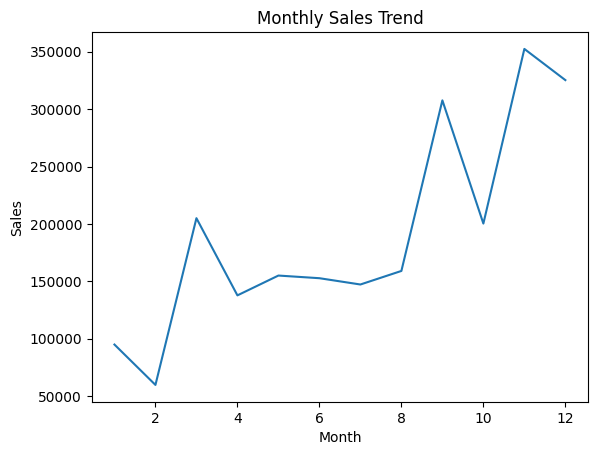

In [6]:
import matplotlib.pyplot as plt

df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### QUARTERLY ANALYSIS

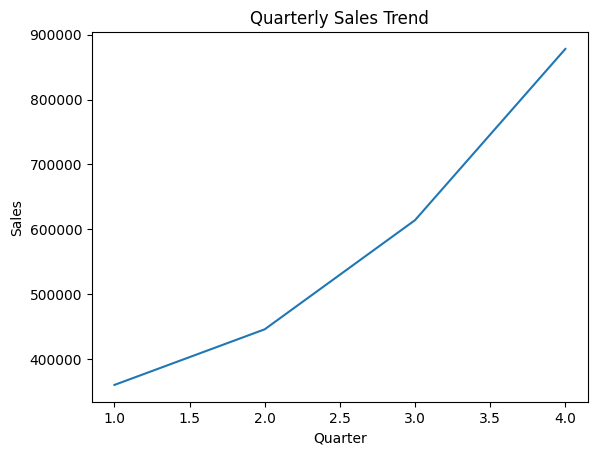

In [7]:
quarterly_sales = df.groupby(df['Order Date'].dt.quarter)['Sales'].sum()

quarterly_sales.plot(kind='line')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

### Observation:
Sales change across different months and quarters. Some periods have higher sales while others are lower.

### Insight:
This shows seasonal trends in business. The company can focus more on high-performing months and plan strategies for low-performing periods.

## CUSTOMER ANALYSIS

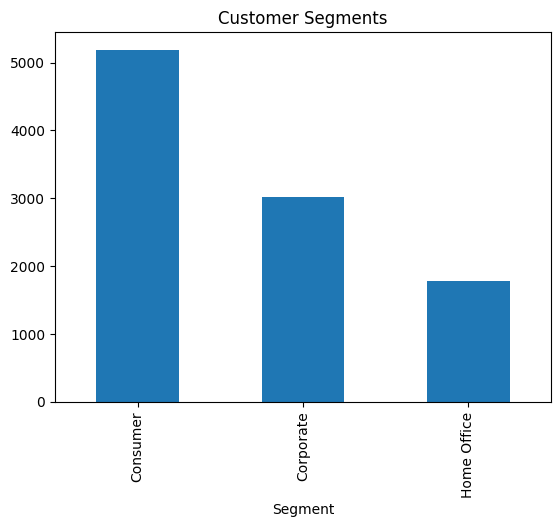

In [11]:
df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

### Observation:
The Consumer segment has the highest number of transactions compared to Corporate and Home Office.

### Insight:
The business mainly depends on individual customers. Marketing strategies should focus more on this segment.

## PRODUCT ANALYSIS

### TOP 10 PRODUCTS

### SALES BY CATEGORY

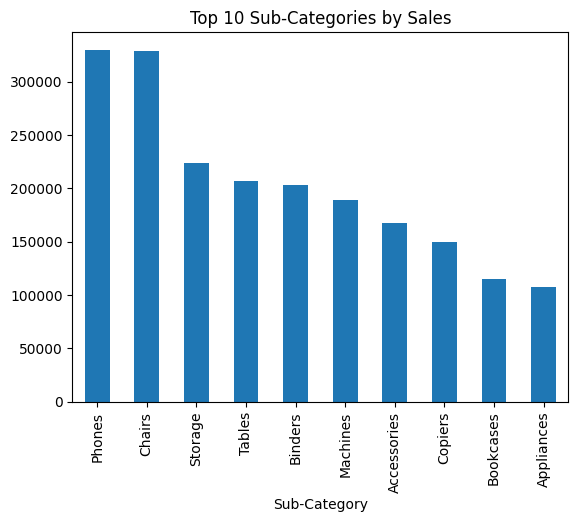

In [15]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Sub-Categories by Sales")
plt.show()


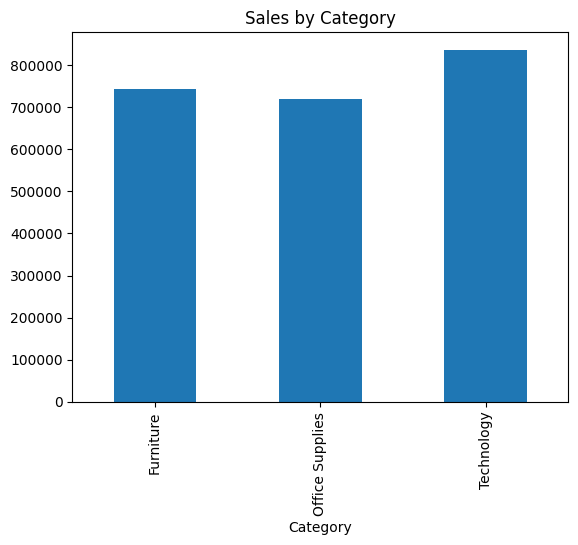

In [9]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

### Observation:
Some sub-categories are sold more frequently. The Technology category generates the highest sales compared to others.

### Insight:
Technology products are in high demand. The company should focus more on these products and ensure availability.

## HEATMAP

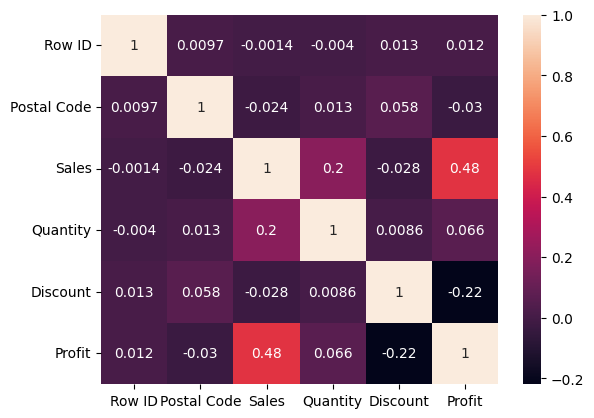

In [10]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

Observation:
The heatmap shows the correlation between numerical variables.
Some variables have positive or negative relationships.

Insight:
Sales and profit are not perfectly correlated, meaning higher sales do not always result in higher profit.

## EXTRA VISUALIZATION

## SALES BY REGION

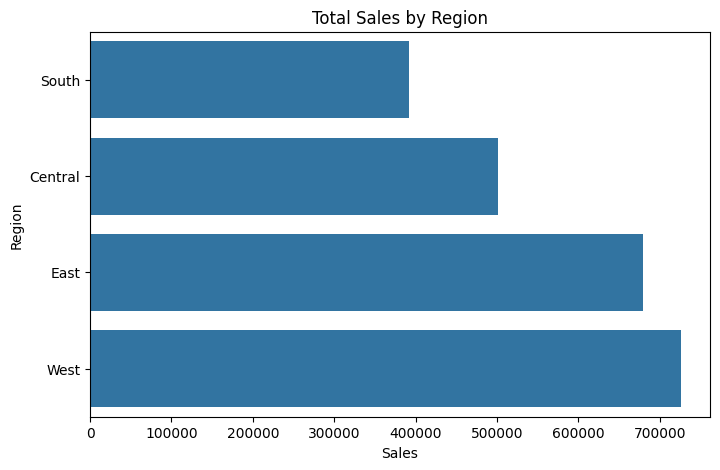

In [13]:
# Sales by Region
import matplotlib.pyplot as plt
import seaborn as sns

region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.values, y=region_sales.index)

plt.title("Total Sales by Region")
plt.xlabel("Sales")
plt.ylabel("Region")

plt.show()

Observation:
The bar chart shows total sales across different regions.
We can clearly see that some regions generate significantly higher revenue than others.

This indicates that demand and business performance vary by location.

Insight:
High-performing regions should be prioritized for marketing and inventory expansion.
Low-performing regions may need targeted promotions or further investigation to improve sales, which impacts profits.

## SALES vs PROFIT SCATTER PLOT

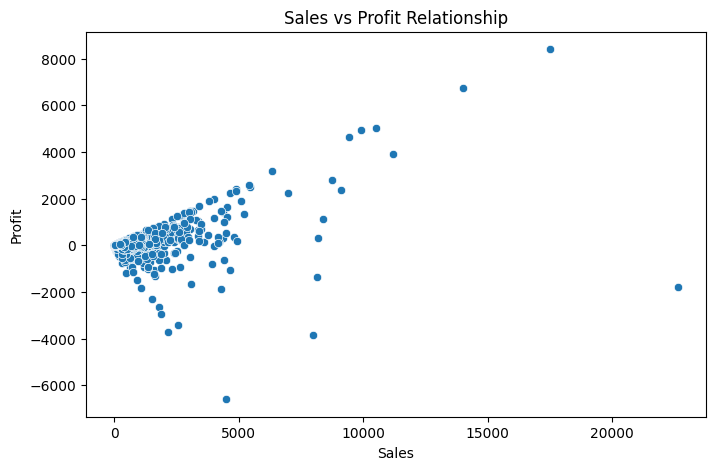

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title("Sales vs Profit Relationship")

plt.show()

Observation:
The scatter plot shows the relationship between sales and profit.
While many transactions generate profit, some high-sales transactions result in losses.

Insight:
This suggests that high sales do not always guarantee profitability.
Discounts, costs, or pricing strategies may be affecting profit margins.

## CONCLUSION AND  BUSINESS RECOMMENDATIONS



After performing Exploratory Data Analysis on the retail sales dataset, several important insights were discovered.

Sales performance is not consistent across all regions. Some regions contribute significantly higher revenue, while others lag behind. Product-wise analysis shows that only a few sub-categories generate the majority of sales, especially in the Technology category.

Another key finding is that high sales do not always lead to high profit. Some transactions result in losses, which indicates issues related to pricing, discount strategies, or cost management.

Overall, business performance depends on region, product demand, and effective profit control.

BUSINESS RECOMENDATION

1 Focus on high-performing regions

Regions with strong sales should be prioritized with better inventory, targeted marketing, and promotional strategies to maximize profit. Low-performing regions should be analyzed and improved with new strategies.

2 Optimize product strategy

Top-selling products should always be in stock to avoid missed revenue opportunities. Low-performing products should be reviewed, improved, or discontinued if necessary.

3 Improve profit management

Since some high-sales transactions result in losses, the company should reduce excessive discounts and optimize pricing strategies to ensure profitability.